### 0. Data Loading

In [133]:
# Imports

import pandas as pd
import os
from panelsplit.cross_validation import PanelSplit
from panelsplit.plot import plot_splits
from panelsplit.application import cross_val_fit_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

In [ ]:
target = pd.read_excel('emdat_target_variable.xlsx') # epidemics

files = []

for filename in os.listdir():
    if filename.endswith(".csv"):
        files.append(filename)

for idx, file in enumerate(files):
    df = pd.read_csv(file)
    df = df.dropna(subset=['Country Code'])
    df = df.set_index(['Series Name', 'Country Code'])
    df = df.drop(['Series Code', 'Country Name'], axis=1)
    
    if(idx==0):
        regressors = df.copy()
    
    else:
        regressors = regressors.join(df)

regressors

### 1. Data Pre-processing

In [65]:
regressors.columns = regressors.columns.str.extract(r'(\d{4})', expand=False)
regressors.columns.name = 'Year'

reg_final = (regressors
             .stack()
             .unstack('Series Name')
             .reset_index()
            )

reg_final.columns.name = None

reg_final.sample(10)

,Country Code,Year,ARI treatment (% of children under 5 taken to a health provider),Capital health expenditure (% of GDP),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)","Cause of death, by injury (% of total)","Cause of death, by non-communicable diseases (% of total)","Cause of death, by other COVID-19 pandemic-related outcomes (% of total)",Children with fever receiving antimalarial drugs (% of children under age 5 with fever),"Community health workers (per 1,000 people)",...,"People with basic handwashing facilities including soap and water, rural (% of rural population)","People with basic handwashing facilities including soap and water, urban (% of urban population)",Proportion of population pushed or further pushed below the $3.65 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure (%),Proportion of population spending more than 25% of household consumption or income on out-of-pocket health care expenditure (%),"Specialist surgical workforce (per 100,000 population)","Tuberculosis case detection rate (%, all forms)","Tuberculosis death rate (per 100,000 people)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Use of insecticide-treated bed nets (% of under-5 population)
4704,ETH,1984,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
9949,MEA,1964,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
13254,RWA,2019,..,..,38.9549322520303,10.2164066359867,50.8286611119831,0,..,..,...,14.1819236879089,26.9011076698066,..,..,..,71,4.9,87,47,..
16432,UZB,2012,..,0.00133966309011295,..,..,..,..,..,..,...,..,..,..,..,43.58,59,9.5,84,..,..
14114,SSF,1969,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
9364,LUX,1964,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4021,EAP,2016,..,..,..,..,..,..,..,..,...,..,..,..,..,..,64,12,90,..,..
8126,KNA,1961,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3595,DEU,1980,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
10277,MLI,1967,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..


In [70]:
target_clean = target[['ISO', 'Start Year']].copy()
target_clean.columns = ['Country Code', 'Year']
target_clean['epidemic'] = 1

target_clean['Year'] = target_clean['Year'].astype(str)
reg_final['Year'] = reg_final['Year'].astype(str)

data = pd.merge(reg_final, target_clean, on=['Country Code', 'Year'], how='left')

data['epidemic'] = data['epidemic'].fillna(0)

data = data.set_index(['Country Code', 'Year'])
data

ARI treatment (% of children under 5 taken to a health provider)  \
Country Code Year                                                                    
ABW          1960                                                 ..                 
             1961                                                 ..                 
             1962                                                 ..                 
             1963                                                 ..                 
             1964                                                 ..                 
...                                                              ...                 
ZWE          2020                                                 ..                 
             2021                                                 ..                 
             2022                                                 ..                 
             2023                                                 ..                 
             2024                                                 ..                 

                  Capital health expenditure (% of GDP)  \
Country Code Year                                         
ABW          1960                                    ..   
             1961                                    ..   
             1962                                    ..   
             1963                                    ..   
             1964                                    ..   
...                                                 ...   
ZWE          2020                     0.102404842676804   
             2021                                    ..   
             2022                                    ..   
             2023                                    ..   
             2024                                    ..   

                  Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
Country Code Year                                                                                                         
ABW          1960                                                 ..                                                      
             1961                                                 ..                                                      
             1962                                                 ..                                                      
             1963                                                 ..                                                      
             1964                                                 ..                                                      
...                                                              ...                                                      
ZWE          2020                                   47.0598923577095                                                      
             2021                                   49.3668994897261                                                      
             2022                                                 ..                                                      
             2023                                                 ..                                                      
             2024                                                 ..                                                      

                  Cause of death, by injury (% of total)  \
Country Code Year                                          
ABW          1960                                     ..   
             1961                                     ..   
             1962                                     ..   
             1963                                     ..   
             1964                                     ..   
...                                                  ...   
ZWE          2020                       9.020691469

In [126]:
from sklearn.impute import SimpleImputer

# 1. Reset index temporarily if you need to fix the Year type
data = data.reset_index()
data['Year'] = data['Year'].astype(int) # Ensure Year is an integer to match range(1960, 2025)
data = data.set_index(['Country Code', 'Year'])

# 2. Define X and y
X = data.drop(['epidemic'], axis=1)
y = data['epidemic']

# 3. Convert all X columns to numeric, coercing any remaining weird strings to NaN
X = X.apply(pd.to_numeric, errors='coerce')

# 4. Impute missing values (using the median of each column as an example)
# Note: In a strict time-series setting, you might want to use grouped interpolation, 
# but SimpleImputer is the best starting point to get the model running.
imputer = SimpleImputer(strategy='median')
X_imputed_array = imputer.fit_transform(X)

# Convert the NumPy array back to a Pandas DataFrame to keep your column names and index
X = pd.DataFrame(X_imputed_array, columns=X.columns, index=X.index)

# (Optional check) Ensure no NaNs are left
print("Remaining NaNs:", X.isna().sum().sum())

Remaining NaNs: 0


### 2. Panel Split

In [136]:
# 1. Extract the spatial groups (Country Codes) and temporal periods (Years) directly from your X index
country_groups = X.index.get_level_values('Country Code')
years = X.index.get_level_values('Year')

horizon = 2

# 2. Initialize the spatio-temporal PanelSplitter
panel_split = PanelSplit(
    periods=years,          # Use the actual years from your dataset
    n_splits=12,            # 12 Temporal splits
    gap=horizon - 1,
    test_size=1,
    groups=country_groups,  # Tell it which rows belong to which countries
    group_splitter=StratifiedGroupKFold(n_splits=3) # 3 spatial splits per temporal split
)

# 1. Initialize the balanced model
rf_model = RandomForestClassifier(class_weight="balanced", random_state=960)

# 2. PRE-COMPUTE the splits explicitly by passing X and y
computed_splits = panel_split.split(X=X, y=y)

# 3. Run the cross-validation using the pre-computed splits
preds, models = cross_val_fit_predict(
    rf_model,
    X=X,
    y=y,
    method="predict_proba",
    cv=computed_splits,  # <--- Pass the computed splits here instead of panel_split!
)

print(preds[:10])

d:\Users\Eric\Desktop\BSE\Forecasting and Nowcasting with Text as Data\homework_1\forecasting_epidemics\.venv\Lib\site-packages\panelsplit\cross_validation.py:173: UserWarning: Could not cleanly pre-generate spatial splits in __init__: Supported target types are: ('binary', 'multiclass'). Got 'unknown' instead.. Passing X and y to split() natively at runtime.
  warnings.warn(


[[1.   0.  ]
 [1.   0.  ]
 [0.99 0.01]
 [1.   0.  ]
 [1.   0.  ]
 [0.99 0.01]
 [1.   0.  ]
 [0.99 0.01]
 [0.99 0.01]
 [1.   0.  ]]


In [145]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# 1. Extract all row indices that were actually used in the test sets
all_test_indices = []
for train_idx, test_idx in computed_splits:
    all_test_indices.extend(test_idx)

# 2. Sort them (panelsplit's predict function outputs predictions in the original dataframe's order)
sorted_test_indices = np.sort(all_test_indices)

# 3. Slice your original 'y' to get the true values ONLY for the tested rows
y_test_aligned = y.iloc[sorted_test_indices]

# 4. Extract just the probabilities for the positive class (Column 1)
y_probs = preds[:, 1]
y_pred_hard = (y_probs >= 0.1).astype(int)

# 5. Evaluate!
roc_auc = roc_auc_score(y_test_aligned, y_probs)
pr_auc = average_precision_score(y_test_aligned, y_probs)

print("=== MODEL EVALUATION ===")
print(f"Rows evaluated: {len(y_test_aligned)}")
print(f"ROC-AUC Score:  {roc_auc:.3f} (1.0 is perfect, 0.5 is random guessing)")
print(f"PR-AUC Score:   {pr_auc:.3f} (Higher is better)\n")

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_aligned, y_pred_hard))

=== MODEL EVALUATION ===
Rows evaluated: 3229
ROC-AUC Score:  0.822 (1.0 is perfect, 0.5 is random guessing)
PR-AUC Score:   0.266 (Higher is better)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       0.97      0.78      0.86      2988
         1.0       0.21      0.72      0.32       241

    accuracy                           0.77      3229
   macro avg       0.59      0.75      0.59      3229
weighted avg       0.91      0.77      0.82      3229



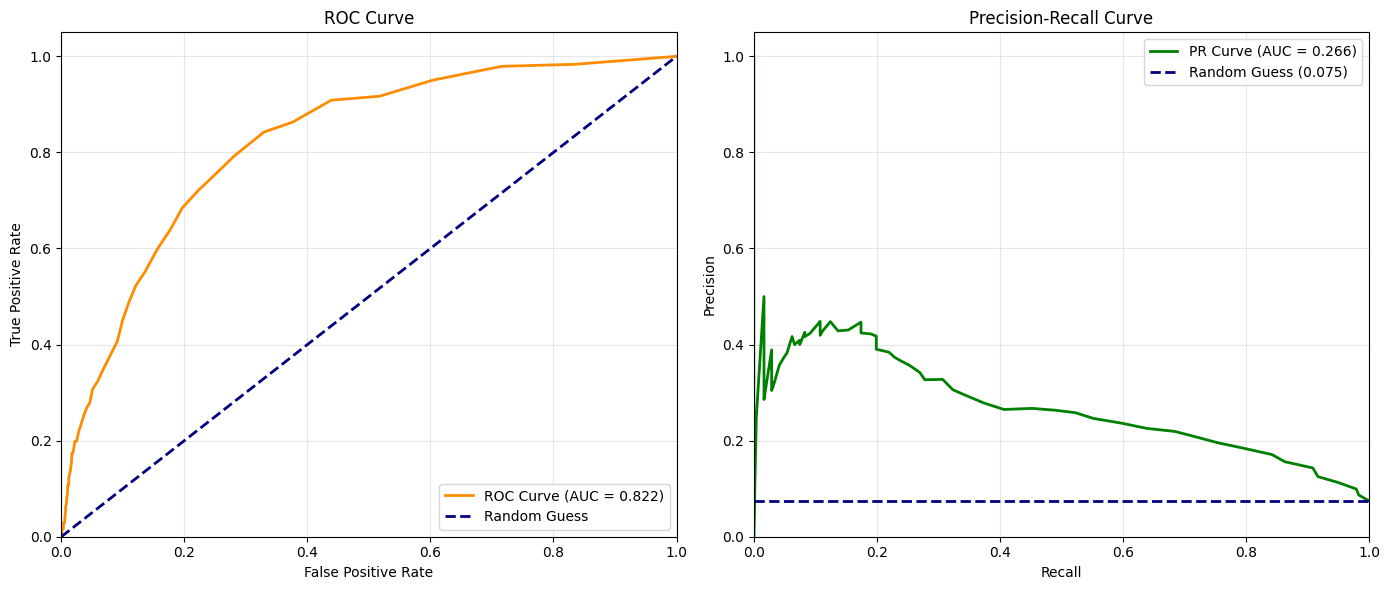

In [146]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# Set up the figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 1. Receiver Operating Characteristic (ROC)
# ==========================================
fpr, tpr, _ = roc_curve(y_test_aligned, y_probs)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# ==========================================
# 2. Precision-Recall (PR) Curve
# ==========================================
precision, recall, _ = precision_recall_curve(y_test_aligned, y_probs)

# The baseline for a PR curve is just the raw percentage of epidemics in your test set
baseline = y_test_aligned.sum() / len(y_test_aligned)

axes[1].plot(recall, precision, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[1].axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Random Guess ({baseline:.3f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

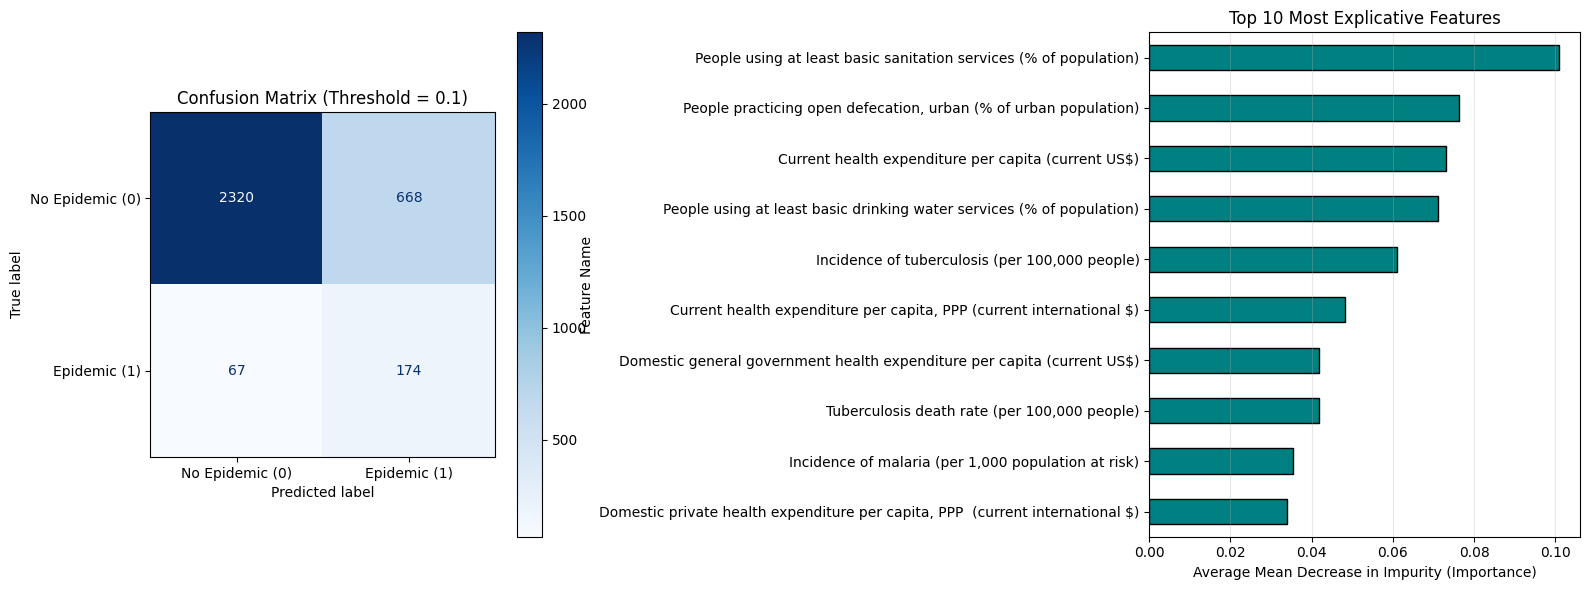

In [148]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# 1. Confusion Matrix (Using custom threshold)
# ==========================================
# Assuming you still have y_test_aligned and y_pred_custom (e.g., from the 0.2 threshold)
cm = confusion_matrix(y_test_aligned, y_pred_hard)

# Create the display object
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['No Epidemic (0)', 'Epidemic (1)']
)
disp.plot(ax=axes[0], cmap='Blues', values_format='d') # 'd' formats numbers as integers
axes[0].set_title(f'Confusion Matrix (Threshold = {0.1})')

# ==========================================
# 2. Top 10 Feature Importances
# ==========================================
# Extract feature importances from ALL fitted models and average them
all_importances = np.array([m.feature_importances_ for m in models])
avg_importances = np.mean(all_importances, axis=0)

# Create a pandas Series to easily sort and plot
feat_importances = pd.Series(avg_importances, index=X.columns)

# Get the top 10 and sort ascending so the biggest bar is at the top of the plot
top_10_features = feat_importances.sort_values(ascending=True).tail(10)

# Plot the horizontal bar chart
top_10_features.plot(kind='barh', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Top 10 Most Explicative Features')
axes[1].set_xlabel('Average Mean Decrease in Impurity (Importance)')
axes[1].set_ylabel('Feature Name')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()